# PowerMamba: A Deep State Space Model and Comprehensive Benchmark for Time Series Prediction in Electric Power Systems.

[Project Github](https://github.com/alimenati/PowerMamba)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


-----

### Data

In [ ]:
# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------
def generate_synthetic_power_data(days=365, interval_min=15):
    """Generates synthetic power usage data."""
    # f(t) = sin(t) + 0.5sin(t/7) + noise + 10
    # noise is Gaussian noise, mean = 0, std = 0.1
    total_steps = int(days * 24 * 60 / interval_min)
    t = np.linspace(0, days * 2 * np.pi, total_steps)
    daily = np.sin(t) 
    weekly = 0.5 * np.sin(t / 7)
    noise = np.random.normal(0, 0.1, total_steps)
    power = daily + weekly + noise + 10.0
    power = (power - power.min()) / (power.max() - power.min())
    return torch.tensor(power, dtype=torch.float32).unsqueeze(-1)



def get_station_metadata(station_num, df):
    """
    Retrieves metadata for a specific station number.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe (metaData).
        
    Returns:
        dict: A dictionary containing all processed metadata for the station.
    """
    
    # 1. Format the station ID (e.g., 5 -> 'station05')
    # zfill(2) ensures '5' becomes '05', but leaves '10' as '10'
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    # Check if station exists to prevent errors
    if station_row.empty:
        return f"Error: Station ID {station_id_str} not found."
    
    # Get the single row as a Series for easy access
    row = station_row.iloc[0]

    # --- Helper to parse the "Key:Value\nKey:Value" strings ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # 3. Parse complex columns
    module_items = parse_kv_string(row['Module'])
    inverter_items = parse_kv_string(row['Inverters'])

    # 4. Build the final dictionary
    # Note: We use .get() for the parsed items to safely handle missing keys
    result_dict = {
        'Station_ID': station_id_str, # Added ID for reference
        'Capacity': row['Capacity'],
        'pv_tech': row['PV_Technology'],
        'Panel_Size': row['Panel_Size'],
        
        # Parsed Module Items
        'Module_Pmax': module_items.get('Pmax'),
        'Module_Vmpp': module_items.get('Vmpp'),
        'Module_Impp': module_items.get('Impp'),
        
        # Parsed Inverter Items
        'Inverter_Max_DC_input': inverter_items.get('Max. DC input'),
        'Inverter_Max_DC_voltage': inverter_items.get('Max. DC voltage'),
        'Inverter_Max_DC_current': inverter_items.get('Max. DC current'),
        'Inverter_Max_DC_Rated_power': inverter_items.get('Rated power'),
        
        'Layout': row['Layout'],
        'Panel_Number': row['Panel_Number'],
        'Array_Tilt': row['Array_Tilt'],
        'Longitude': row['Longitude'],
        'Latitude': row['Latitude']
    }
    
    return result_dict


def calculate_clearsky_index(metadata, df):
    """
    Calculates Clear Sky Power (P_CLR) and PV Clear Sky Index (K_PV).
    Scales the simulation to the full station capacity and handles DataFrame outputs safely.
    """
    
    # ---------------------------------------------------------
    # 1. PARSE METADATA
    # ---------------------------------------------------------
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"Processing Station: {station_id}")
    
    def extract_num(s):
        if isinstance(s, (int, float)): return float(s)
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(s))
        return float(match.group()) if match else 0.0

    # Parse Layout
    layout_str = metadata.get('Layout', '')
    mod_per_string = 20 # default
    str_per_inv = 100   # default
    
    if 'modules per string' in layout_str:
        try:
            mod_per_string = int(extract_num(layout_str.split('modules per string:')[1].split('\n')[0]))
            str_per_inv = int(extract_num(layout_str.split('strings per inverter:')[1]))
        except:
            print("Warning: Could not parse Layout string, using defaults.")

    # Parse Tilt & Azimuth
    tilt_str = metadata.get('Array_Tilt', 'South 30')
    tilt = extract_num(tilt_str)
    
    azimuth = 180 
    if 'North' in tilt_str: azimuth = 0
    elif 'East' in tilt_str: azimuth = 90
    elif 'West' in tilt_str: azimuth = 270

    # ---------------------------------------------------------
    # 2. SETUP LOCATION & WEATHER
    # ---------------------------------------------------------
    # Copy df to avoid SettingWithCopy warnings on the original
    df = df.copy()
    
    if 'date_time' in df.columns:
        df = df.set_index('date_time')
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Handle duplicates
    if df.index.duplicated().any():
        df = df[~df.index.duplicated(keep='first')]

    lat = metadata.get('Latitude', 38.0)
    lon = metadata.get('Longitude', 114.0)
    
    site_location = location.Location(lat, lon, tz='UTC') 

    print("Generating clear sky irradiance data...")
    clearsky_weather = site_location.get_clearsky(df.index, model='ineichen')

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Using PVWatts Inverter Model)
    # ---------------------------------------------------------
    temp_params = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

    # --- Module Parameters ---
    sandia_modules = pvsystem.retrieve_sam('SandiaMod')
    module_template = sandia_modules.columns[0]
    module_params = sandia_modules[module_template].copy()
    
    # Overwrite electrical specs from metadata
    module_params['Impo'] = extract_num(metadata.get('Module_Impp', 8.0))
    module_params['Vmpo'] = extract_num(metadata.get('Module_Vmpp', 30.0))
    module_params['Isco'] = module_params['Impo'] * 1.05 
    module_params['Voco'] = module_params['Vmpo'] * 1.2
    
    # --- Inverter Parameters & Scaling ---
    panel_watts = extract_num(metadata.get('Module_Pmax', 300))
    
    # DC Capacity of ONE inverter block (Watts)
    block_dc_capacity_watts = (mod_per_string * str_per_inv) * panel_watts
    
    # Station Total Capacity (Watts)
    station_capacity_watts = extract_num(metadata.get('Capacity', 0)) * 1000 
    
    # Calculate Scaling Factor (How many such blocks make up the station?)
    if block_dc_capacity_watts > 0 and station_capacity_watts > 0:
        scaling_factor = station_capacity_watts / block_dc_capacity_watts
    else:
        scaling_factor = 1.0
        
    print(f"Station Capacity: {station_capacity_watts/1e6:.2f} MW")
    print(f"Modeled Block Capacity: {block_dc_capacity_watts/1e6:.2f} MW")
    print(f"Scaling Factor: {scaling_factor:.2f}x")

    inverter_params = {
        'pdc0': block_dc_capacity_watts, 
        'eta_inv_nom': 0.96 
    }

    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_params,
        modules_per_string=mod_per_string,
        strings_per_inverter=str_per_inv,
        temperature_model_parameters=temp_params
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN
    # ---------------------------------------------------------
    mc = modelchain.ModelChain(
        system, 
        site_location,
        transposition_model="perez",
        solar_position_method="nrel_numpy",
        aoi_model="physical",
        spectral_model="no_loss",
        ac_model='pvwatts'
    )

    print("Running simulation...")
    try:
        mc.run_model(clearsky_weather)
    except Exception as e:
        print(f"Simulation failed: {e}")
        return df

    # ---------------------------------------------------------
    # 5. PROCESS RESULTS (Fixing ValueError)
    # ---------------------------------------------------------
    ac_output = mc.results.ac
    
    # FIX: Ensure output is a Series, summing if it's a DataFrame
    if isinstance(ac_output, pd.DataFrame):
        ac_output = ac_output.sum(axis=1)
        
    # Scale to full station capacity
    p_clr_watts = ac_output * scaling_factor
    
    # Convert to MW
    p_clr_mw = p_clr_watts / 1_000_000
    p_clr_mw = p_clr_mw.fillna(0).clip(lower=0)
    
    # Assign to DataFrame
    df['P_CLR'] = p_clr_mw
    
    # Calculate K_PV (Clear Sky Index)
    if 'power' in df.columns:
        # Filter small P_CLR values to avoid division by zero artifacts
        df['K_PV'] = np.where(df['P_CLR'] > 0.1, df['power'] / df['P_CLR'], 0.0)
    else:
        print("Warning: 'power' column not found. K_PV not calculated.")

    return df




In [26]:
# read the data for PVOD
abs_path = os.path.abspath("../PVODdatasets_v1")

station03_path = os.path.join(abs_path, "station03.csv")
station03_data = pd.read_csv(station03_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)

station_03_meta = get_station_metadata(3, metaData)
station_03_meta

{'Station_ID': 'station03',
 'Longitude': 114.11494,
 'Latitude': 38.10956,
 'Array_Tilt': 'South 33°',
 'Capacity': 20000.0,
 'Panel_Size': 1.62,
 'Total_Panel_Number': 75460,
 'PV_Technology': 'Poly-Si',
 'Module_Pmax': 265.0,
 'Module_Vmpp': 30.93,
 'Module_Impp': 8.57,
 'Inverter_Rated_Power': 1000.0,
 'Inverter_Max_DC_Voltage': 1000.0,
 'Modules_per_String': 22,
 'Strings_per_Inverter': 16}

In [27]:
station03_data = pd.read_csv(station03_path)

In [28]:
# ==========================================================
# Real Power PV generated power data.

station03_data = pd.read_csv(station03_path)


# 3. Run Calculation
station03_df = calculate_clearsky_indices(station_03_meta, station03_data)

--- Processing Station: station03 ---
Calculating theoretical Clear Sky GHI...
Running PV Power Simulation...


In [29]:
station03_df.head()

,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power,GHI_clr,K_CS,P_CLR,K_PV
1970-01-01 00:00:00.000000000,2019-01-11 16:00:00,0.0,0.0,-0.07,44.66,1.50,234.97,989.14,0,0.0,-2.8,988.5,48,1.0,0.0,13.999935,0.0,0.0,0.0
1970-01-01 00:00:00.000000001,2019-01-11 16:15:00,0.0,0.0,-0.13,45.23,1.59,238.49,989.14,0,0.0,-2.8,988.5,138,1.0,0.0,13.999935,0.0,0.0,0.0
1970-01-01 00:00:00.000000002,2019-01-11 16:30:00,0.0,0.0,-0.15,45.60,1.67,246.38,989.25,0,0.0,-2.8,988.5,40,1.0,0.0,13.999935,0.0,0.0,0.0
1970-01-01 00:00:00.000000003,2019-01-11 16:45:00,0.0,0.0,-0.17,45.86,1.77,255.51,989.31,0,0.0,-3.9,988.5,130,1.0,0.0,13.999935,0.0,0.0,0.0
1970-01-01 00:00:00.000000004,2019-01-11 17:00:00,0.0,0.0,-0.21,46.08,1.88,262.02,989.08,0,0.0,-3.9,988.5,158,1.0,0.0,13.999935,0.0,0.0,0.0


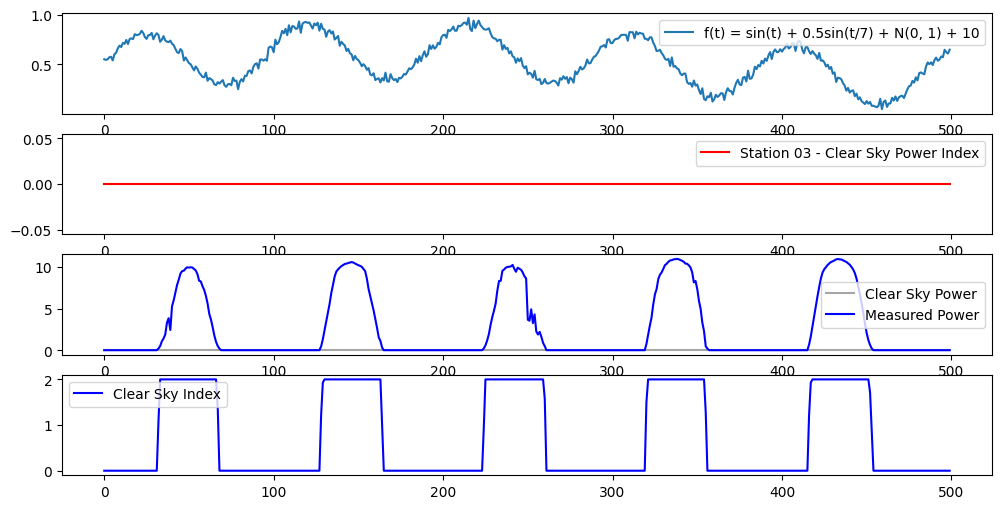

In [ ]:


synthitic_power = generate_synthetic_power_data().numpy()
t = np.linspace(0, synthitic_power.shape[0], synthitic_power.shape[0])
plt.figure(figsize=(12, 6))
plt.subplot(4, 1, 1)
plt.plot(t[:500], synthitic_power[:500], label='f(t) = sin(t) + 0.5sin(t/7) + N(0, 1) + 10')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t[:500], station03_df['K_PV'][:500], label='Station 03 - Clear Sky Power Index', color='red')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t[:500], station03_df['P_CLR'][:500], label='Clear Sky Power', color='black', alpha=0.35)

plt.plot(t[:500], station03_df['power'][:500], label='Measured Power', color='blue')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(t[:500], station03_df['K_CS'][:500], label='Clear Sky Index', color='blue')
plt.legend()

plt.show()

In [47]:
def prepare_features(df):
    data = df.copy()
    
    # 1. Cyclic Encoding for Hour (0-23)
    # This helps the model know that 23:00 is close to 00:00
    data['hour_sin'] = np.sin(2 * np.pi * data.index.hour / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data.index.hour / 24)
    
    # 2. Cyclic Encoding for Day of Year (1-365)
    # This captures seasonality (Summer vs Winter)
    data['day_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['day_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)
    
    
    
    return data


station03_df = prepare_features(station03_df)




In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

----

#### Data Preparation and Dataset

In [49]:
import os
import numpy as np
import pandas as pd
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

from typing import List


class MultiStepDataset(Dataset):
    """
    prepare data set for the model. As X is the past F features, Y is the target and P is the prediction features, 
    seq_len
    Returns:
        x_past   : [seq_len, F]
        y_future : [pred_len, 1]
        x_future : [pred_len, F]
    """
    def __init__(self, X, Y, P, seq_len=96, pred_len=96): # One day back and Forward.
        self.X = X  # numpy array [T, F]
        self.y = Y  # numpy array [T, 1] (K_PV)
        self.P = P  # numpy array [T, F]
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len + 1

    def __getitem__(self, i):
        # past window
        x_past = self.X[i : i + self.seq_len]  # [seq_len, F]

        # future horizon
        start_fut = i + self.seq_len
        end_fut   = start_fut + self.pred_len

        y_future = self.y[start_fut : end_fut]         # [pred_len, 1]
        x_future = self.P[start_fut : end_fut]         # [pred_len, F]

        return (
            torch.tensor(x_past,   dtype=torch.float32),
            torch.tensor(y_future, dtype=torch.float32),
            torch.tensor(x_future, dtype=torch.float32),
        )

class Dataset_Pred(Dataset):
    def __init__(self, root_path, flag='pred', size=None,
                 features='S', data_path='ETTh1.csv',
                 target=['OT'], scale=True, inverse=False, timeenc=0, freq='15min', cols=None):
        # size [seq_len, label_len, pred_len]
        # info
        if size == None:
            self.seq_len = 24 * 4 * 4
            self.label_len = 24 * 4
            self.pred_len = 24 * 4
        else:
            self.seq_len = size[0]
            self.label_len = size[1]
            self.pred_len = size[2]
        # init
        assert flag in ['pred']

        self.features = features
        self.target = target
        self.scale = scale
        self.inverse = inverse
        self.timeenc = timeenc
        self.freq = freq
        self.cols = cols
        self.root_path = root_path
        self.data_path = data_path
        self.__read_data__()

    def __read_data__(self):
        self.scaler = StandardScaler()
        df_raw = pd.read_csv(os.path.join(self.root_path,
                                          self.data_path))
        '''
        df_raw.columns: ['date', ...(other features), target feature]
        '''
        if self.cols:
            cols = self.cols.copy()
            cols.remove(self.target)
        else:
            cols = list(df_raw.columns)
            cols.remove(self.target)
            cols.remove('date')
        df_raw = df_raw[['date'] + cols + self.target]
        border1 = len(df_raw) - self.seq_len
        border2 = len(df_raw)

        if self.features == 'M' or self.features == 'MS' or self.features == 'Mm':
            cols_data = df_raw.columns[1:]
            df_data = df_raw[cols_data]
        elif self.features == 'S':
            df_data = df_raw[[self.target]]

        if self.scale:
            self.scaler.fit(df_data.values)
            data = self.scaler.transform(df_data.values)
        else:
            data = df_data.values

        tmp_stamp = df_raw[['date']][border1:border2]
        tmp_stamp['date'] = pd.to_datetime(tmp_stamp.date)
        pred_dates = pd.date_range(tmp_stamp.date.values[-1], periods=self.pred_len + 1, freq=self.freq)

        df_stamp = pd.DataFrame(columns=['date'])
        df_stamp.date = list(tmp_stamp.date.values) + list(pred_dates[1:])
        if self.timeenc == 0:
            df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
            df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
            df_stamp['weekday'] = df_stamp.date.apply(lambda row: row.weekday(), 1)
            df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
            df_stamp['minute'] = df_stamp.date.apply(lambda row: row.minute, 1)
            df_stamp['minute'] = df_stamp.minute.map(lambda x: x // 15)
            data_stamp = df_stamp.drop(['date'], axis=1).values
        elif self.timeenc == 1:
            data_stamp = time_features(pd.to_datetime(df_stamp['date'].values), freq=self.freq)
            data_stamp = data_stamp.transpose(1, 0)

        self.data_x = data[border1:border2]
        if self.inverse:
            self.data_y = df_data.values[border1:border2]
        else:
            self.data_y = data[border1:border2]
        self.data_stamp = data_stamp

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = self.data_x[s_begin:s_end]
        if self.inverse:
            seq_y = self.data_x[r_begin:r_begin + self.label_len]
        else:
            seq_y = self.data_y[r_begin:r_begin + self.label_len]
        seq_x_mark = self.data_stamp[s_begin:s_end]
        seq_y_mark = self.data_stamp[r_begin:r_end]

        return seq_x, seq_y, seq_x_mark, seq_y_mark

    def __len__(self):
        return len(self.data_x) - self.seq_len + 1

    def inverse_transform(self, data):
        return self.scaler.inverse_transform(data)





import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader

def prepare_rolling_folds(
    df, input_cols, target_col, prediction_cols,
    n_splits=5, seq_len=96, pred_len=96, batch_size=32
):
    X_raw = df[input_cols].values.astype(np.float32)
    P_raw = df[prediction_cols].values.astype(np.float32)
    
    # --- FIX: Removed double brackets [[...]] ---
    # target_col is already a list ['K_PV'], so df[target_col] works correctly
    y_raw = df[target_col].values.astype(np.float32)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold = 0
    for train_index, test_index in tscv.split(X_raw):
        fold += 1
        
        # Split Data
        X_train_fold = X_raw[train_index]
        P_train_fold = P_raw[train_index]
        y_train_fold = y_raw[train_index]

        X_test_fold = X_raw[test_index]
        P_test_fold = P_raw[test_index]
        y_test_fold = y_raw[test_index]

        # Prepend Lookback for Test Set
        # We need the last 'seq_len' points from train to predict the first point of test
        X_lookback = X_train_fold[-seq_len:]
        P_lookback = P_train_fold[-seq_len:]
        y_lookback = y_train_fold[-seq_len:]

        X_test_final = np.concatenate([X_lookback, X_test_fold], axis=0)
        P_test_final = np.concatenate([P_lookback, P_test_fold], axis=0)
        y_test_final = np.concatenate([y_lookback, y_test_fold], axis=0)

        # Create Datasets
        train_dataset = MultiStepDataset(
            X_train_fold, y_train_fold, P_train_fold, seq_len=seq_len, pred_len=pred_len
        )
        test_dataset = MultiStepDataset(
            X_test_final, y_test_final, P_test_final, seq_len=seq_len, pred_len=pred_len
        )

        # Create Loaders
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        yield train_loader, test_loader

----

## Model

In [50]:
import torch
import torch.nn as nn

class RevIN(nn.Module):
    def __init__(self, num_features: int, eps=1e-2, affine=True):
        """
        :param num_features: the number of features or channels
        :param eps: a value added for numerical stability
        :param affine: if True, RevIN has learnable affine parameters
        """
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else: raise NotImplementedError
        return x

    def _init_params(self):
        # initialize RevIN params: (C,)
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps*self.eps)
        x = x * self.stdev
        x = x + self.mean
        return x


------

In [51]:
class moving_avg(torch.nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = torch.nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x
        

class series_decomp(torch.nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean



In [52]:
from mamba_ssm import Mamba
class Model(torch.nn.Module):
    def __init__(self,configs):
        super(Model, self).__init__()
        self.configs=configs
        
        self.enc_in = len(self.configs.PAST_INPUT_COLS) + self.configs.num_shadows
        # Prevents token size from expanding excessively while retaining predictive info.
        # "squeezes" the enriched information back to the original context length L so that the model's complexity does not scale with the size of the prediction window.
        self.lin1=torch.nn.Linear(2*(self.configs.seq_len+self.configs.pred_len),self.configs.seq_len)

        # Find the indices of the target columns
        self.target_indices = [
            self.configs.PAST_INPUT_COLS.index(col) 
            for col in self.configs.TARGET_COL
        ]
        
        # NOTE: What is the size affect on.
        kernel_size = self.configs.kernel_size
        self.decompsition = series_decomp(kernel_size)
        
        self.revin_layer = RevIN(self.configs.enc_in)
        self.revin_layer_enc = RevIN(self.configs.enc_in)
        
        # By combining these different views, PowerMamba achieves a 7% improvement in prediction error while using 43% fewer parameters than other Mamba-based models.
        self.lin2=torch.nn.Linear(2*(self.configs.seq_len),self.configs.n_embed)

        self.lin3=torch.nn.Linear(4*self.configs.n_embed,self.configs.pred_len)
        
        self.dropout1=torch.nn.Dropout(self.configs.dropout)
        self.dropout2=torch.nn.Dropout(self.configs.dropout)

        # The Temporal Expert: captures intra-series dependencies (patterns within a single time series)
        self.mamba1 = Mamba(d_model=self.configs.n_embed,d_state=self.configs.d_state,d_conv=self.configs.dconv,
                            expand = self.configs.e_fact)
        # The Feature Expert: captures inter-series relationships (how different features like Temperature and Global Irradiation interact with each other at a specific moment)
        self.mamba2 = Mamba(d_model=self.configs.enc_in,d_state=self.configs.d_state,d_conv=self.configs.dconv,
                            expand = self.configs.e_fact)

    def forward(self, x, x_f, y):
        # Assumption x is the input historical features (B, L, C) with Length of L. 
        # x_f is the prediction features (B, H, C) H is horizon or prediction length, C is the number of features
        # y is the target (B, H, 1)
        # All x, x_f, y are of shape (batch_size, seq_len{L,H}, feature_size)

        
        batch_size = x.size(0)

        # 1. Initialize the Expanded Tensor
        # Width = Original Past Cols + Shadow Cols
        x_pred = torch.zeros(batch_size, self.configs.seq_len + self.configs.pred_len, self.configs.enc_in).to(x.device)


        # 2. Fill the "Past" section with historical data x
        # We fill the first N columns (where N = len(PAST_INPUT_COLS))
        num_past_feats = len(self.configs.PAST_INPUT_COLS)
        x_pred[:, :self.configs.seq_len, :num_past_feats] = x

        # 3. Dynamic Shadow Feature Generation
        # We start filling shadow columns *after* the original features
        shadow_col_start_idx = num_past_feats

        for i, feature_name in enumerate(self.configs.common_features):
            # A. Find indices dynamically
            past_idx = self.configs.PAST_INPUT_COLS.index(feature_name)
            fut_idx  = self.configs.FUTURE_INPUT_COLS.index(feature_name)
            
            # B. Extract the forecast from x_f
            # shape: [Batch, H]
            forecast_values = x_f[:, :, fut_idx]
            
            # C. ALIGNMENT: Fill the future hole of the *original* column
            # This ensures the model sees the forecast as a continuation of the past
            x_pred[:, self.configs.seq_len:, past_idx] = forecast_values
            
            # D. SHIFTING: Create the Shadow Column
            # Shadow column index = Start of shadows + current iteration
            current_shadow_idx = shadow_col_start_idx + i
            # FIX: Resize forecast_values to match seq_len if they differ
            if self.configs.seq_len != self.configs.pred_len:
                # 1. Add dimension for interpolation: [Batch, 1, H]
                f_val_reshaped = forecast_values.unsqueeze(1)
                
                # 2. Interpolate to Length L: [Batch, 1, L]
                f_val_resized = torch.nn.functional.interpolate(
                    f_val_reshaped, 
                    size=self.configs.seq_len, 
                    mode='linear', 
                    align_corners=False
                )
                
                # 3. Remove extra dimension: [Batch, L]
                shadow_values = f_val_resized.squeeze(1)
            else:
                shadow_values = forecast_values
            
            # Shift Logic: The future forecast is copied into the PAST rows of the shadow column.
            # D. Fill the Shadow Column (Now safe even if lengths differ)
            x_pred[:, :self.configs.seq_len, current_shadow_idx] = shadow_values
            
            # Fill the future part of the shadow column (Use original forecast length)
            x_pred[:, self.configs.seq_len:, current_shadow_idx] = forecast_values

        # 4. Standard PowerMamba Processing
        x = x_pred # x is now size [Batch, L+H, enc_in]
        
        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)
        
        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x) # Squeeze back to L
        x = torch.permute(x, (0, 2, 1))
        
        x = self.revin_layer_enc(x, 'denorm')
        
        
        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e= torch.cat([seasonal_init, trend_init], dim=1)

        x_e = torch.permute(x_e, (0,2,1))
        x_e = self.lin2(x_e)
        
        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        x_im = torch.permute(x_im, (0,2,1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0,2,1))
        

        x = torch.cat([x_im, x_m, x_m+x_im, x_e], dim=2)
        
        # Project to Prediction Horizon [Batch, enc_in, pred_len]
        x = self.lin3(x)
        
        # Permute to [Batch, pred_len, enc_in]
        x = torch.permute(x, (0,2,1))
        # Denormalize ALL features first (RevIN expects enc_in channels)
        x = self.revin_layer(x, 'denorm')

        x = x[:, :, self.target_indices] # Shape becomes [32, 3, 1]

        return x


In [53]:
def train_one_epoch(model, loader, optimizer, criterion, teacher_forcing_ratio):
    model.train()
    total_loss = 0.0


    for x_past, y_future, x_future in loader:
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        preds = model(x_past, x_future, y_future)

        loss = criterion(preds, y_future)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_fold(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, None)

            loss = criterion(preds, y_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)   # [N, T, 1]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, T, 1]

    # Flatten for global metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

In [54]:
import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses, fold_num):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title(f'Fold {fold_num} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

class MambaModelConfigs:
    def __init__(self):
        # --- 1. Data Dimensions ---
        self.seq_len = 672    # L: Look-back window
        self.pred_len = 96     # H: Prediction horizon

        # Define  features by name

        self.PAST_INPUT_COLS = ['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature',
        'power', 'K_PV',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
        self.FUTURE_INPUT_COLS = ['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature']
        self.TARGET_COL = ['K_PV']
        
        # --- 2. Dynamic Shadow Calculation ---
        # Identify which features exist in both Past and Future (Intersection)
        self.common_features = [f for f in self.FUTURE_INPUT_COLS if f in self.PAST_INPUT_COLS]
        self.num_shadows = len(self.common_features)
        
        # Flag to enable external prediction logic (1 = True, 0 = False)
        self.include_pred = 1 if len(self.FUTURE_INPUT_COLS) > 0 else 0

        # --- 3. Model Input Width ---
        # enc_in = Original Past Features + Shadow Features
        # The model needs this total width to initialize RevIN and Mamba layers
        self.enc_in = len(self.PAST_INPUT_COLS) + self.num_shadows
        
        self.c_out = len(self.TARGET_COL)
        
        self.kernel_size = 5  
        self.n_embed = 128     
        self.d_state = 128      # The size of the latent "hidden state". A larger d_state allows the model to remember more complex dynamics from the past
        self.dconv = 4         # Mamba uses a small local convolution to smooth the input before the state space processing, which helps capture local temporal patterns.
        self.e_fact = 2        # (Expansion Factor): This determines the internal "width" of the block. It projects the input to a higher dimension to find non-linear patterns before projecting it back
        self.dropout = 0.20

        self.n_splits = 2 
        self.batch_size = 32
        self.epochs = 100
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        
def run_rolling_cv(df, configs):
    results = []
    history = {}

    fold_gen = prepare_rolling_folds(

        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Training Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = Model(configs).to(device)

        # criterion = PhysicsGuidedLoss(
        #     w_data=1.0,
        #     w_phys=1e-2,
        #     w_night=1e-3,
        #     w_cap=1e-3,
        #     w_nonneg=1e-3
        # ).to(device)
        criterion = nn.MSELoss().to(device)

        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()),
            lr=1e-3
        )

        for epoch in range(configs.epochs):
            # linear decay of teacher forcing
            tf_ratio = max(0.0, 0.5 - epoch / (configs.epochs * 0.8))

            train_loss = train_one_epoch(
                model, train_loader, optimizer, criterion, tf_ratio
            )
            val_loss, val_rmse, val_mae = evaluate_fold(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(
                    f"Epoch {epoch+1:03d} | TF={tf_ratio:.2f} | "
                    f"Train={train_loss:.4f} | Val={val_loss:.4f} | "
                    f"RMSE={val_rmse:.4f} | MAE={val_mae:.4f}"
                )

        _, final_rmse, final_mae = evaluate_fold(model, test_loader, criterion)
        print(f"--> Fold {fold} Finished: RMSE={final_rmse:.4f}, MAE={final_mae:.4f}")

        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

        plot_loss_curve(history[fold]['train'], history[fold]['val'], fold)

    avg_rmse = np.mean([r['rmse'] for r in results])
    print("\n=== Final Cross-Validation Results ===")
    print(f"Average RMSE: {avg_rmse:.4f}")

    return results, history

In [55]:
station03_df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'P_CLR', 'K_PV',
       'hour_sin', 'hour_cos', 'day_sin', 'day_cos'],
      dtype='object')

In [56]:
df = station03_df.copy()


=== Training Fold 1/2 ===
Epoch 005 | TF=0.45 | Train=0.0083 | Val=0.1362 | RMSE=0.3676 | MAE=0.2117
Epoch 010 | TF=0.39 | Train=0.0064 | Val=0.1326 | RMSE=0.3628 | MAE=0.1965
Epoch 015 | TF=0.33 | Train=0.0056 | Val=0.1287 | RMSE=0.3572 | MAE=0.1922
Epoch 020 | TF=0.26 | Train=0.0056 | Val=0.1322 | RMSE=0.3621 | MAE=0.2013
Epoch 025 | TF=0.20 | Train=0.0054 | Val=0.1266 | RMSE=0.3543 | MAE=0.1941
Epoch 030 | TF=0.14 | Train=0.0045 | Val=0.1280 | RMSE=0.3562 | MAE=0.1958
Epoch 035 | TF=0.08 | Train=0.0058 | Val=0.1354 | RMSE=0.3666 | MAE=0.2065
Epoch 040 | TF=0.01 | Train=0.0081 | Val=0.1301 | RMSE=0.3593 | MAE=0.2017
Epoch 045 | TF=0.00 | Train=0.0047 | Val=0.1328 | RMSE=0.3629 | MAE=0.2019
Epoch 050 | TF=0.00 | Train=0.0042 | Val=0.1364 | RMSE=0.3678 | MAE=0.2051
Epoch 055 | TF=0.00 | Train=0.0043 | Val=0.1417 | RMSE=0.3751 | MAE=0.2115
Epoch 060 | TF=0.00 | Train=0.0042 | Val=0.1463 | RMSE=0.3811 | MAE=0.2175
Epoch 065 | TF=0.00 | Train=0.0037 | Val=0.1517 | RMSE=0.3884 | MAE=0.224

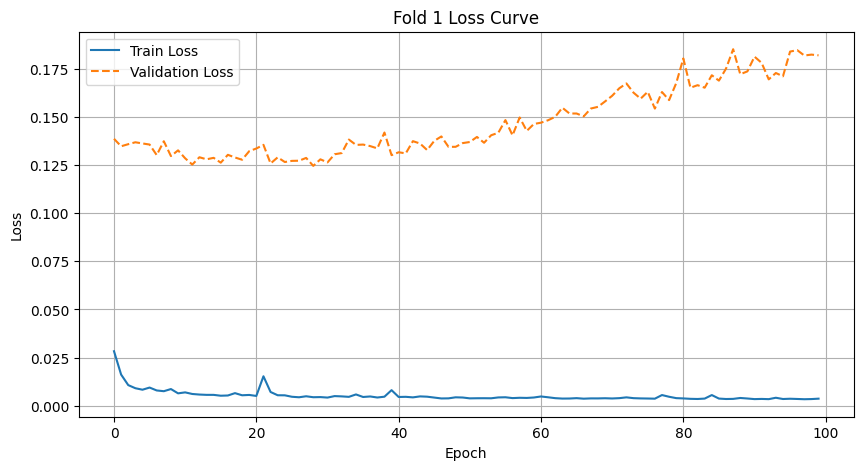


=== Training Fold 2/2 ===
Epoch 005 | TF=0.45 | Train=0.0404 | Val=0.1428 | RMSE=0.3776 | MAE=0.2179
Epoch 010 | TF=0.39 | Train=0.0331 | Val=0.1422 | RMSE=0.3769 | MAE=0.2165
Epoch 015 | TF=0.33 | Train=0.0314 | Val=0.1564 | RMSE=0.3952 | MAE=0.2343
Epoch 020 | TF=0.26 | Train=0.0295 | Val=0.1463 | RMSE=0.3823 | MAE=0.2246
Epoch 025 | TF=0.20 | Train=0.0276 | Val=0.1455 | RMSE=0.3812 | MAE=0.2212
Epoch 030 | TF=0.14 | Train=0.0286 | Val=0.1452 | RMSE=0.3807 | MAE=0.2206
Epoch 035 | TF=0.08 | Train=0.0258 | Val=0.1391 | RMSE=0.3728 | MAE=0.2138
Epoch 040 | TF=0.01 | Train=0.0257 | Val=0.1409 | RMSE=0.3751 | MAE=0.2131
Epoch 045 | TF=0.00 | Train=0.0240 | Val=0.1362 | RMSE=0.3689 | MAE=0.2110
Epoch 050 | TF=0.00 | Train=0.0260 | Val=0.1431 | RMSE=0.3783 | MAE=0.2189
Epoch 055 | TF=0.00 | Train=0.0253 | Val=0.1418 | RMSE=0.3764 | MAE=0.2144
Epoch 060 | TF=0.00 | Train=0.0276 | Val=0.1413 | RMSE=0.3754 | MAE=0.2167
Epoch 065 | TF=0.00 | Train=0.0234 | Val=0.1447 | RMSE=0.3799 | MAE=0.222

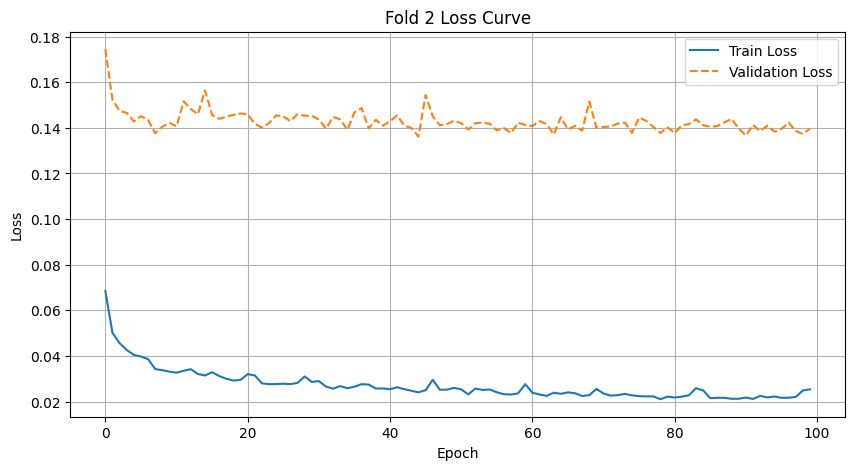


=== Final Cross-Validation Results ===
Average RMSE: 0.3993


In [57]:

configs = MambaModelConfigs()
results01, history01 = run_rolling_cv(df, configs)



Plotting Sample 0...


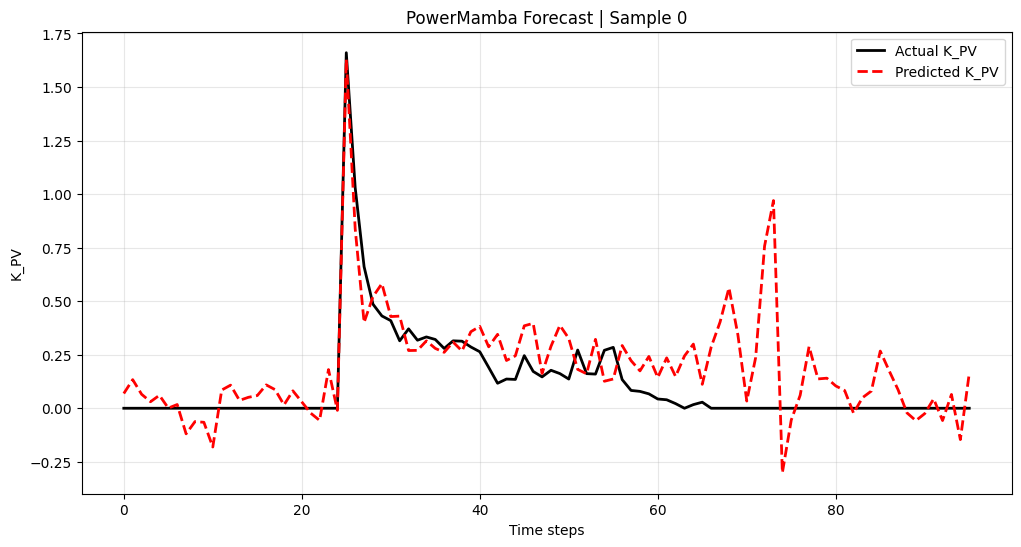

In [96]:
import matplotlib.pyplot as plt
import torch

def plot_prediction_sample(model, loader, sample_idx=0):
    model.eval()
    
    # 1. Get a batch from the loader
    x_past, y_future, x_future = next(iter(loader))

    # 2. Move to device (Dynamic check ensures safety)
    device = next(model.parameters()).device
    x_past   = x_past.to(device)
    y_future = y_future.to(device)
    x_future = x_future.to(device)

    with torch.no_grad():
        # --- FIX: Call model with the correct signature (x, x_f, y) ---
        # We pass y_future as the 3rd argument because the forward definition requires it,
        # even though PowerMamba inference doesn't strictly depend on it.
        preds = model(x_past, x_future, y_future)

    # 3. Extract the specific sample for plotting
    # Output shape is [Batch, H, 1] -> Remove batch & feature dim -> [H]
    pred_seq   = preds[sample_idx, :, 0].cpu().numpy()   
    actual_seq = y_future[sample_idx, :, 0].cpu().numpy()

    # 4. Plot
    plt.figure(figsize=(12, 6))
    plt.plot(actual_seq, label='Actual K_PV', color='black', linewidth=2)
    plt.plot(pred_seq, label='Predicted K_PV', color='red', linestyle='--', linewidth=2)
    
    plt.title(f'PowerMamba Forecast | Sample {sample_idx}')
    plt.xlabel('Time steps')
    plt.ylabel('K_PV')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Run the Plotter ---
last_fold = results01[-1]
model_final = last_fold['model']
loader_final = last_fold['test_loader']

print("Plotting Sample 0...")
plot_prediction_sample(model_final, loader_final, sample_idx=0)


----

In [19]:
import torch
import torch.nn as nn

class PhysicsGuidedLoss(nn.Module):
    def __init__(
        self,
        g_idx,         # <--- NEW: Index of Global Irradiance in x_future
        t_idx,         # <--- NEW: Index of Temperature in x_future
        w_data=1.0,
        w_phys=0.1,    # Increased slightly for visibility
        w_night=0.1,
        w_cap=0.1,
        w_nonneg=0.1,
        G_day_thr=10.0,
        G_night_thr=5.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        
        # Store indices
        self.g_idx = g_idx
        self.t_idx = t_idx
        
        self.w_data   = w_data
        self.w_phys   = w_phys
        self.w_night  = w_night
        self.w_cap    = w_cap
        self.w_nonneg = w_nonneg

        # Learnable parameters
        self.k_ross = nn.Parameter(torch.tensor(0.03))  
        self.gamma  = nn.Parameter(torch.tensor(0.004)) 
        self.T_ref  = 25.0

        self.G_day_thr   = G_day_thr
        self.G_night_thr = G_night_thr

    def forward(self, preds, targets, future_inputs):
        device = preds.device
        preds_k   = preds.squeeze(-1)    
        targets_k = targets.squeeze(-1)  

        # 1. Data loss
        loss_data = self.mse(preds_k, targets_k)

        # 2. Physical inputs (Dynamic Indexing)
        G     = future_inputs[:, :, self.g_idx] # [B,T]
        T_amb = future_inputs[:, :, self.t_idx] # [B,T]

        # 3. Ross temperature
        T_c = T_amb + self.k_ross * G

        # 4. Physics baseline K_phys
        K_phys = 1.0 - self.gamma * (T_c - self.T_ref)
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # Daylight physics loss
        daylight_mask = G > self.G_day_thr
        if daylight_mask.any():
            loss_phys = self.mse(preds_k[daylight_mask], K_phys[daylight_mask])
        else:
            loss_phys = torch.zeros((), device=device)

        # Night boundary
        night_mask = G < self.G_night_thr
        if night_mask.any():
            loss_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            loss_night = torch.zeros((), device=device)

        # Capacity & Non-negativity
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        loss_cap = torch.mean(over_cap ** 2) if over_cap.numel() > 0 else torch.zeros((), device=device)

        under_zero = torch.clamp(-preds_k, min=0.0)
        loss_nonneg = torch.mean(under_zero ** 2) if under_zero.numel() > 0 else torch.zeros((), device=device)

        total_loss = (
            self.w_data   * loss_data +
            self.w_phys   * loss_phys +
            self.w_night  * loss_night +
            self.w_cap    * loss_cap +
            self.w_nonneg * loss_nonneg
        )

        return total_loss

In [20]:
def train_one_epoch_physics(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        # Move to device
        device = next(model.parameters()).device
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        # Forward Pass
        preds = model(x_past, x_future, y_future)

        # --- DIFFERENCE IS HERE ---
        # We pass x_future to the criterion so it can extract G and T
        loss = criterion(preds, y_future, x_future)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_fold_physics(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    device = next(model.parameters()).device

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, y_future)

            # Calculate Physics Loss for validation tracking
            loss = criterion(preds, y_future, x_future)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)

    # Flatten for metrics
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

In [21]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    # --- 1. Identify Indices for Physics Loss ---
    # We look up where 'nwp_globalirrad' and 'nwp_temperature' are in the FUTURE columns
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        print(f"Physics Loss Configuration: Irradiance Index={idx_g}, Temp Index={idx_t}")
    except ValueError as e:
        print("Error: 'nwp_globalirrad' or 'nwp_temperature' not found in FUTURE_INPUT_COLS")
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Physics Experiment Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        # Instantiate Model
        model = Model(configs).to(device)

        # --- 2. Instantiate Physics Loss ---
        criterion = PhysicsGuidedLoss(
            g_idx=idx_g,
            t_idx=idx_t,
            w_data=1.0, w_phys=0.35, w_night=0.3, w_cap=0.3, w_nonneg=0.5,
            G_day_thr=10.0, G_night_thr=5.0
        ).to(device)

        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()), # Include learnable physics params
            lr=1e-3
        )

        for epoch in range(configs.epochs): # Adjust EPOCHS as needed
            # Use the NEW training function
            train_loss = train_one_epoch_physics(
                model, train_loader, optimizer, criterion
            )
            
            # Use the NEW evaluation function
            val_loss, val_rmse, val_mae = evaluate_fold_physics(
                model, test_loader, criterion
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1:03d} | Train Loss={train_loss:.4f} | Val RMSE={val_rmse:.4f}")

        # Final Evaluation
        _, final_rmse, final_mae = evaluate_fold_physics(model, test_loader, criterion)
        
        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

    return results, history

In [22]:
# 1. Setup Configs (Same as before)
configs = MambaModelConfigs()

# 2. Run the Physics Experiment
print("Starting Physics-Guided Training...")
phys_results, phys_history = run_physics_experiment(df, configs)

# 3. Compare Results
print(f"Physics RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Physics-Guided Training...
Physics Loss Configuration: Irradiance Index=0, Temp Index=1

=== Physics Experiment Fold 1/2 ===
Epoch 002 | Train Loss=0.1021 | Val RMSE=0.3862
Epoch 004 | Train Loss=0.0901 | Val RMSE=0.4255
Epoch 006 | Train Loss=0.0809 | Val RMSE=0.4041
Epoch 008 | Train Loss=0.0770 | Val RMSE=0.3882
Epoch 010 | Train Loss=0.0821 | Val RMSE=0.3930
Epoch 012 | Train Loss=0.0800 | Val RMSE=0.3930
Epoch 014 | Train Loss=0.0734 | Val RMSE=0.3901
Epoch 016 | Train Loss=0.0727 | Val RMSE=0.4405
Epoch 018 | Train Loss=0.0755 | Val RMSE=0.4054
Epoch 020 | Train Loss=0.0695 | Val RMSE=0.3998
Epoch 022 | Train Loss=0.0726 | Val RMSE=0.4092
Epoch 024 | Train Loss=0.0681 | Val RMSE=0.4125
Epoch 026 | Train Loss=0.0679 | Val RMSE=0.4049
Epoch 028 | Train Loss=0.0712 | Val RMSE=0.4197
Epoch 030 | Train Loss=0.0700 | Val RMSE=0.4011
Epoch 032 | Train Loss=0.0707 | Val RMSE=0.4166
Epoch 034 | Train Loss=0.0680 | Val RMSE=0.4136
Epoch 036 | Train Loss=0.0722 | Val RMSE=0.4123
Ep

Plotting Sample 0...


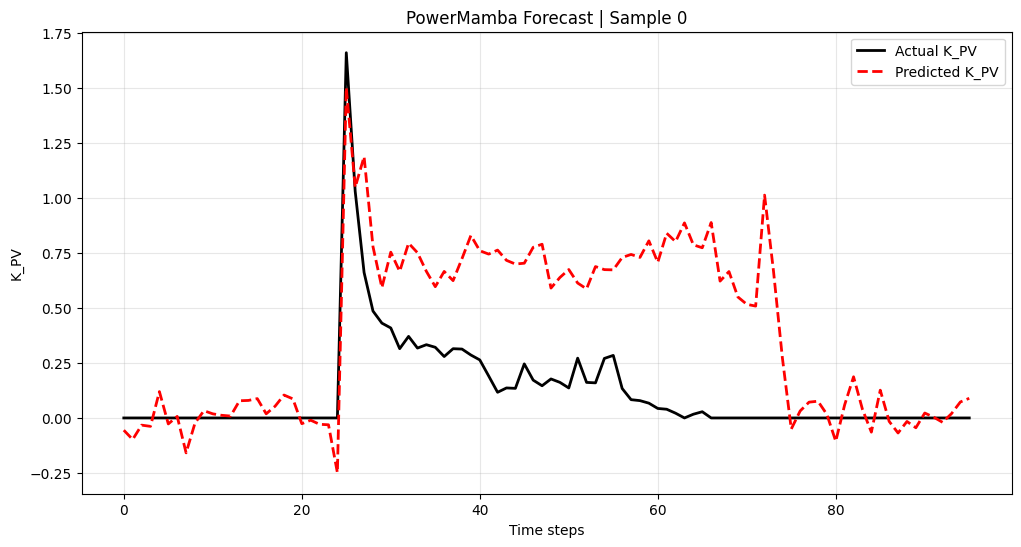

Plotting Sample 20...


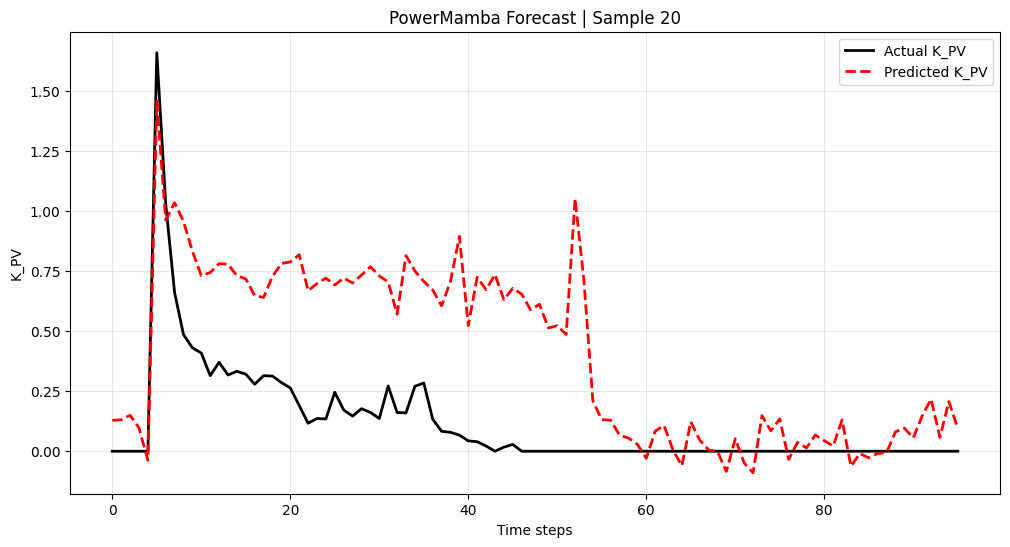

In [23]:
# --- Run the Plotter ---
last_fold = phys_results[-1]
model_final = last_fold['model']
loader_final = last_fold['test_loader']

print("Plotting Sample 0...")
plot_prediction_sample(model_final, loader_final, sample_idx=0)

print("Plotting Sample 20...")
plot_prediction_sample(model_final, loader_final, sample_idx=20)

------

In [36]:
import torch
import torch.nn as nn
import numpy as np

class LearnablePhysicsLoss(nn.Module):
    def __init__(
        self,
        g_idx,
        t_idx,
        warmup_epochs=5,  # <--- NEW: Number of epochs to ignore physics
        G_day_thr=10.0,
        G_night_thr=5.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        
        self.g_idx = g_idx
        self.t_idx = t_idx
        self.warmup_epochs = warmup_epochs
        
        self.G_day_thr = G_day_thr
        self.G_night_thr = G_night_thr

        # --- Learnable Physics Parameters ---
        # We start with reasonable scientific guesses
        self.k_ross = nn.Parameter(torch.tensor(0.03))  
        self.gamma  = nn.Parameter(torch.tensor(0.004)) 
        self.T_ref  = 25.0

        # --- Learnable Weights (Log Variances) ---
        # [Data, Phys, Night, Cap, NonNeg]
        # Index 0 (Data): Init 0.0 (Weight ~ 0.5)
        # Index 1-4 (Phys): Init 4.0 (Weight ~ 0.018) -> Starts with very low importance
        self.log_vars = nn.Parameter(torch.tensor([0.0, 4.0, 4.0, 4.0, 4.0]))

    def forward(self, preds, targets, future_inputs, current_epoch=999):
        """
        current_epoch: Passed from training loop to control warm-up
        """
        device = preds.device
        preds_k   = preds.squeeze(-1)    
        targets_k = targets.squeeze(-1)  

        # --- 1. Calculate Raw Losses ---
        
        # A. Data Loss (Always Active)
        L_data = self.mse(preds_k, targets_k)

        # B. Physics Components
        G     = future_inputs[:, :, self.g_idx]
        T_amb = future_inputs[:, :, self.t_idx]
        
        # Ross Model Calculation
        T_c = T_amb + self.k_ross * G
        K_phys = 1.0 - self.gamma * (T_c - self.T_ref)
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # Physics Loss (Daylight)
        daylight_mask = G > self.G_day_thr
        if daylight_mask.any():
            L_phys = self.mse(preds_k[daylight_mask], K_phys[daylight_mask])
        else:
            L_phys = torch.zeros((), device=device)

        # Night Loss
        night_mask = G < self.G_night_thr
        if night_mask.any():
            L_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            L_night = torch.zeros((), device=device)

        # Capacity Loss (K <= 1.0)
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        L_cap = torch.mean(over_cap ** 2) if over_cap.numel() > 0 else torch.zeros((), device=device)

        # Non-negativity Loss (K >= 0.0)
        under_zero = torch.clamp(-preds_k, min=0.0)
        L_nonneg = torch.mean(under_zero ** 2) if under_zero.numel() > 0 else torch.zeros((), device=device)

        # --- 2. Combine with Uncertainty & Warm-up ---
        
        # CLAMP: Prevent variance from exploding (ignoring loss) or vanishing (numerical instability)
        # Range: -2.0 (High weight) to 6.0 (Tiny weight)
        clamped_log_vars = torch.clamp(self.log_vars, min=-2.0, max=6.0)
        
        loss = 0.0
        
        # List of raw losses matching the order of log_vars
        raw_losses = [L_data, L_phys, L_night, L_cap, L_nonneg]

        # WARM-UP LOGIC:
        # If we are in warm-up phase, we ONLY use Index 0 (Data Loss).
        # We skip adding the other terms, effectively "freezing" their impact and parameters.
        active_components = 1 if current_epoch < self.warmup_epochs else 5

        for i in range(active_components):
            raw_loss = raw_losses[i]
            s = clamped_log_vars[i]
            
            # Formula: (1 / 2e^s) * L + s/2
            precision = torch.exp(-s)
            loss += 0.5 * precision * raw_loss + 0.5 * s

        return loss

In [37]:
def train_one_epoch_physics(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0.0

    for x_past, y_future, x_future in loader:
        # Move to device
        device = next(model.parameters()).device
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        # Forward Pass
        preds = model(x_past, x_future, y_future)

        # --- PASS EPOCH FOR WARM-UP ---
        loss = criterion(preds, y_future, x_future, current_epoch=epoch)
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate_fold_physics(model, loader, criterion, epoch):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []

    device = next(model.parameters()).device

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, y_future)

            # Pass epoch to ensure validation loss scale matches training loss scale
            loss = criterion(preds, y_future, x_future, current_epoch=epoch)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)

    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    mae  = np.mean(np.abs(preds_flat - actuals_flat))

    return total_loss / len(loader), rmse, mae

In [38]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    # --- 1. Identify Indices for Physics Loss ---
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
        print(f"Physics Configuration: Irradiance Idx={idx_g}, Temp Idx={idx_t}")
    except ValueError as e:
        print("Error: Required columns not found in FUTURE_INPUT_COLS")
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = Model(configs).to(device)

        # --- 2. Instantiate Loss with Warm-up ---
        criterion = LearnablePhysicsLoss(
            g_idx=idx_g,
            t_idx=idx_t,
            warmup_epochs=5,  # First 5 epochs: Only learn Data MSE
            G_day_thr=10.0
        ).to(device)

        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()), 
            lr=1e-3
        )

        epochs = getattr(configs, 'epochs', 50) 

        for epoch in range(epochs): 
            # Pass 'epoch' to training loop
            train_loss = train_one_epoch_physics(
                model, train_loader, optimizer, criterion, epoch
            )
            
            # Pass 'epoch' to validation loop
            val_loss, val_rmse, val_mae = evaluate_fold_physics(
                model, test_loader, criterion, epoch
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                with torch.no_grad():
                    # Visualize how weights are evolving
                    # Clamping log_vars manually here just for display
                    logs = torch.clamp(criterion.log_vars, -2.0, 6.0)
                    w = torch.exp(-logs).cpu().numpy()
                    
                    status = "WARMUP" if epoch < criterion.warmup_epochs else "PHYSICS ACTIVE"
                    print(f"[{status}] Weights -> Data:{w[0]:.2f} Phys:{w[1]:.2f} Night:{w[2]:.2f}")
                    
                print(f"Epoch {epoch+1:03d} | Loss={train_loss:.4f} | RMSE={val_rmse:.4f}")

        _, final_rmse, final_mae = evaluate_fold_physics(model, test_loader, criterion, epochs)
        
        results.append({
            'fold': fold,
            'rmse': final_rmse,
            'mae': final_mae,
            'model': model,
            'test_loader': test_loader
        })

    return results, history

In [41]:
# 1. Setup Configs
configs = MambaModelConfigs()
configs.n_splits = 2
configs.epochs = 100
# 2. Run
print("Starting Learnable Physics-Guided Training...")
phys_results, phys_history = run_physics_experiment(df, configs)

# 3. Result
print(f"Average RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Learnable Physics-Guided Training...
Physics Configuration: Irradiance Idx=0, Temp Idx=1

=== Fold 1/2 ===
[WARMUP] Weights -> Data:1.18 Phys:0.02 Night:0.02
Epoch 005 | Loss=-0.0698 | RMSE=0.3634
[PHYSICS ACTIVE] Weights -> Data:1.39 Phys:0.02 Night:0.02
Epoch 010 | Loss=7.3048 | RMSE=0.3509
[PHYSICS ACTIVE] Weights -> Data:1.65 Phys:0.03 Night:0.03
Epoch 015 | Loss=6.8033 | RMSE=0.3477
[PHYSICS ACTIVE] Weights -> Data:1.94 Phys:0.04 Night:0.04
Epoch 020 | Loss=6.3428 | RMSE=0.3429
[PHYSICS ACTIVE] Weights -> Data:2.29 Phys:0.04 Night:0.04
Epoch 025 | Loss=5.8999 | RMSE=0.3447
[PHYSICS ACTIVE] Weights -> Data:2.70 Phys:0.05 Night:0.05
Epoch 030 | Loss=5.4661 | RMSE=0.3422
[PHYSICS ACTIVE] Weights -> Data:3.18 Phys:0.06 Night:0.06
Epoch 035 | Loss=5.0394 | RMSE=0.3425
[PHYSICS ACTIVE] Weights -> Data:3.75 Phys:0.07 Night:0.07
Epoch 040 | Loss=4.6166 | RMSE=0.3450
[PHYSICS ACTIVE] Weights -> Data:4.42 Phys:0.09 Night:0.09
Epoch 045 | Loss=4.1967 | RMSE=0.3440
[PHYSICS ACTIVE] W

Plotting Sample 0...


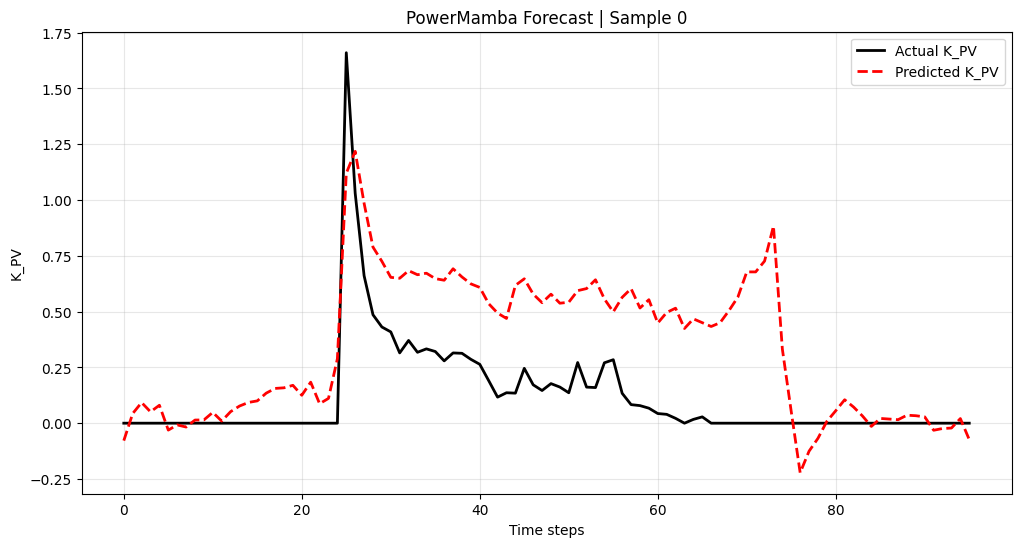

Plotting Sample 20...


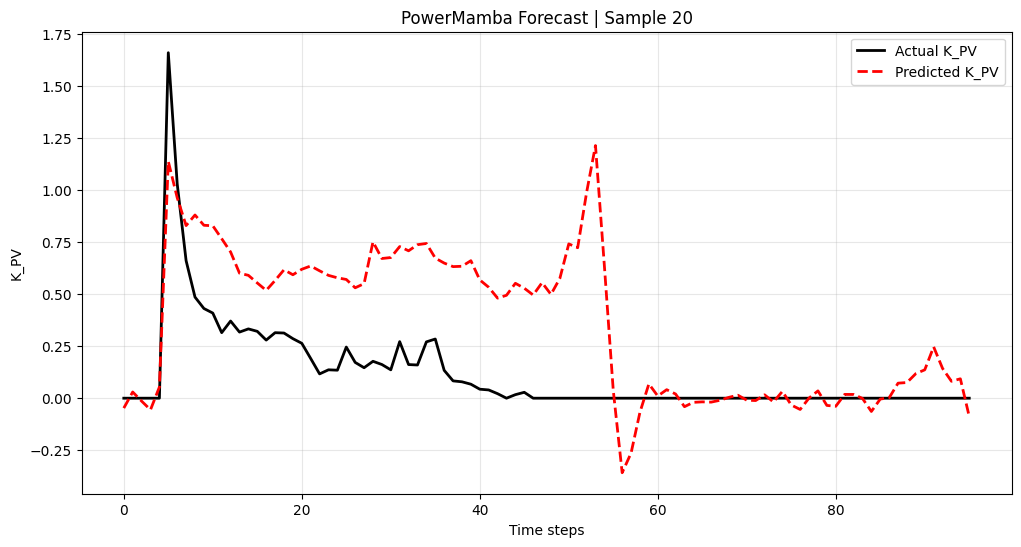

In [42]:
# --- Run the Plotter ---
last_fold = phys_results[-1]
model_final = last_fold['model']
loader_final = last_fold['test_loader']

print("Plotting Sample 0...")
plot_prediction_sample(model_final, loader_final, sample_idx=0)

print("Plotting Sample 20...")
plot_prediction_sample(model_final, loader_final, sample_idx=20)

---

In [73]:
import torch
import torch.nn as nn

class AnnealingPhysicsLoss(nn.Module):
    def __init__(
        self,
        g_idx,
        t_idx,
        # Fixed target weights (tuned for stability)
        w_data=1.0,
        w_phys=0.5,   
        w_night=0.5,
        w_cap=0.5,
        w_nonneg=0.5,
        warmup_epochs=20, # Linearly increase weights over 20 epochs
        G_day_thr=10.0,
        G_night_thr=5.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        
        self.g_idx = g_idx
        self.t_idx = t_idx
        
        # Target weights
        self.w_data   = w_data
        self.w_phys   = w_phys
        self.w_night  = w_night
        self.w_cap    = w_cap
        self.w_nonneg = w_nonneg
        
        self.warmup_epochs = warmup_epochs
        self.G_day_thr = G_day_thr
        self.G_night_thr = G_night_thr

        # KEEP Learnable Physics Parameters (These are good!)
        self.k_ross = nn.Parameter(torch.tensor(0.03))  
        self.gamma  = nn.Parameter(torch.tensor(0.004)) 
        self.T_ref  = 25.0

    def forward(self, preds, targets, future_inputs, current_epoch=0):
        device = preds.device
        preds_k   = preds.squeeze(-1)    
        targets_k = targets.squeeze(-1)  

        # --- 1. Raw Losses ---
        loss_data = self.mse(preds_k, targets_k)

        # Physics Baseline
        G     = future_inputs[:, :, self.g_idx]
        T_amb = future_inputs[:, :, self.t_idx]
        T_c = T_amb + self.k_ross * G
        K_phys = 1.0 - self.gamma * (T_c - self.T_ref)
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # Physics (Day)
        daylight_mask = G > self.G_day_thr
        if daylight_mask.any():
            loss_phys = self.mse(preds_k[daylight_mask], K_phys[daylight_mask])
        else:
            loss_phys = torch.zeros((), device=device)

        # Night
        night_mask = G < self.G_night_thr
        if night_mask.any():
            loss_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            loss_night = torch.zeros((), device=device)

        # Constraints
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        loss_cap = torch.mean(over_cap ** 2) if over_cap.numel() > 0 else torch.zeros((), device=device)

        under_zero = torch.clamp(-preds_k, min=0.0)
        loss_nonneg = torch.mean(under_zero ** 2) if under_zero.numel() > 0 else torch.zeros((), device=device)

        # --- 2. Annealing Logic (The Fix) ---
        # Calculate alpha: 0.0 at epoch 0, 1.0 at epoch 20
        if self.warmup_epochs > 0:
            alpha = min(1.0, current_epoch / self.warmup_epochs)
        else:
            alpha = 1.0

        # Apply weights
        # Data loss is always full strength
        # Physics losses grow stronger over time
        total_loss = (
            self.w_data * loss_data + 
            alpha * (
                self.w_phys * loss_phys + 
                self.w_night * loss_night + 
                self.w_cap * loss_cap + 
                self.w_nonneg * loss_nonneg
            )
        )

        return total_loss, alpha

In [74]:
def train_one_epoch_physics(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0.0
    last_alpha = 0.0

    for x_past, y_future, x_future in loader:
        device = next(model.parameters()).device
        x_past   = x_past.to(device)
        y_future = y_future.to(device)
        x_future = x_future.to(device)

        optimizer.zero_grad()

        preds = model(x_past, x_future, y_future)

        # Get loss AND alpha
        loss, alpha = criterion(preds, y_future, x_future, current_epoch=epoch)
        last_alpha = alpha
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader), last_alpha

def evaluate_fold_physics(model, loader, criterion, epoch):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_actuals = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past   = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            preds = model(x_past, x_future, y_future)
            loss, _ = criterion(preds, y_future, x_future, current_epoch=epoch)
            total_loss += loss.item()

            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())

    preds_arr   = np.concatenate(all_preds, axis=0)
    actuals_arr = np.concatenate(all_actuals, axis=0)
    preds_flat   = preds_arr.reshape(-1)
    actuals_flat = actuals_arr.reshape(-1)

    rmse = np.sqrt(np.mean((preds_flat - actuals_flat) ** 2))
    return total_loss / len(loader), rmse

In [75]:
def run_physics_experiment(df, configs):
    results = []
    history = {}
    
    try: 
        idx_g = configs.FUTURE_INPUT_COLS.index('nwp_globalirrad')
        idx_t = configs.FUTURE_INPUT_COLS.index('nwp_temperature')
    except ValueError as e:
        raise e

    fold_gen = prepare_rolling_folds(
        df, configs.PAST_INPUT_COLS, configs.TARGET_COL, configs.FUTURE_INPUT_COLS,
        n_splits=configs.n_splits,
        seq_len=configs.seq_len,
        pred_len=configs.pred_len,
        batch_size=configs.batch_size
    )

    for i, (train_loader, test_loader) in enumerate(fold_gen):
        fold = i + 1
        print(f"\n=== Annealing Physics Fold {fold}/{configs.n_splits} ===")
        history[fold] = {'train': [], 'val': []}

        model = Model(configs).to(device)

        # --- Instantiate Annealing Loss ---
        criterion = AnnealingPhysicsLoss(
            g_idx=idx_g,
            t_idx=idx_t,
            warmup_epochs=30,  # Slow ramp up over 20 epochs
            w_phys=0.1,        # Final physics weight
            w_night=0.1
        ).to(device)

        optimizer = torch.optim.Adam(
            list(model.parameters()) + list(criterion.parameters()), 
            lr=1e-4
        )

        epochs = getattr(configs, 'epochs', 50) 

        for epoch in range(epochs): 
            train_loss, alpha = train_one_epoch_physics(
                model, train_loader, optimizer, criterion, epoch
            )
            
            val_loss, val_rmse = evaluate_fold_physics(
                model, test_loader, criterion, epoch
            )

            history[fold]['train'].append(train_loss)
            history[fold]['val'].append(val_loss)

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1:03d} | Phys Strength: {alpha*100:.0f}% | Loss={train_loss:.4f} | Val RMSE={val_rmse:.4f}")

        _, final_rmse = evaluate_fold_physics(model, test_loader, criterion, epochs)
        results.append({'fold': fold, 'rmse': final_rmse, 'model': model, 'test_loader': test_loader})

    return results, history

In [76]:
# 1. Setup Configs
configs = MambaModelConfigs()
configs.n_splits = 2
configs.epochs = 100
# 2. Run
print("Starting Learnable Physics-Guided Training...")
phys_results, phys_history = run_physics_experiment(df, configs)

# 3. Result
print(f"Average RMSE: {np.mean([r['rmse'] for r in phys_results]):.4f}")

Starting Learnable Physics-Guided Training...

=== Annealing Physics Fold 1/2 ===
Epoch 005 | Phys Strength: 13% | Loss=0.0187 | Val RMSE=0.3694
Epoch 010 | Phys Strength: 30% | Loss=0.0186 | Val RMSE=0.3574
Epoch 015 | Phys Strength: 47% | Loss=0.0204 | Val RMSE=0.3512
Epoch 020 | Phys Strength: 63% | Loss=0.0231 | Val RMSE=0.3455
Epoch 025 | Phys Strength: 80% | Loss=0.0258 | Val RMSE=0.3406
Epoch 030 | Phys Strength: 97% | Loss=0.0284 | Val RMSE=0.3342
Epoch 035 | Phys Strength: 100% | Loss=0.0283 | Val RMSE=0.3315
Epoch 040 | Phys Strength: 100% | Loss=0.0279 | Val RMSE=0.3301
Epoch 045 | Phys Strength: 100% | Loss=0.0272 | Val RMSE=0.3271
Epoch 050 | Phys Strength: 100% | Loss=0.0269 | Val RMSE=0.3260
Epoch 055 | Phys Strength: 100% | Loss=0.0267 | Val RMSE=0.3271
Epoch 060 | Phys Strength: 100% | Loss=0.0263 | Val RMSE=0.3206
Epoch 065 | Phys Strength: 100% | Loss=0.0264 | Val RMSE=0.3219
Epoch 070 | Phys Strength: 100% | Loss=0.0259 | Val RMSE=0.3205
Epoch 075 | Phys Strength: 1

Plotting Sample 0...


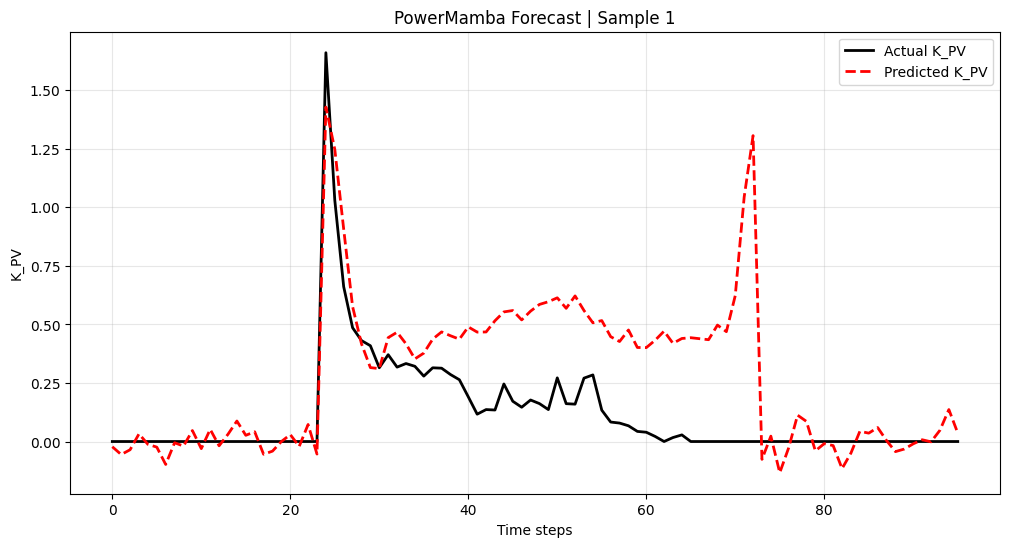

In [80]:
# --- Run the Plotter ---
last_fold = phys_results[-1]
model_final = last_fold['model']
loader_final = last_fold['test_loader']

print("Plotting Sample 0...")
plot_prediction_sample(model_final, loader_final, sample_idx=1)


Stitching 3 days (Horizon=96 steps)...


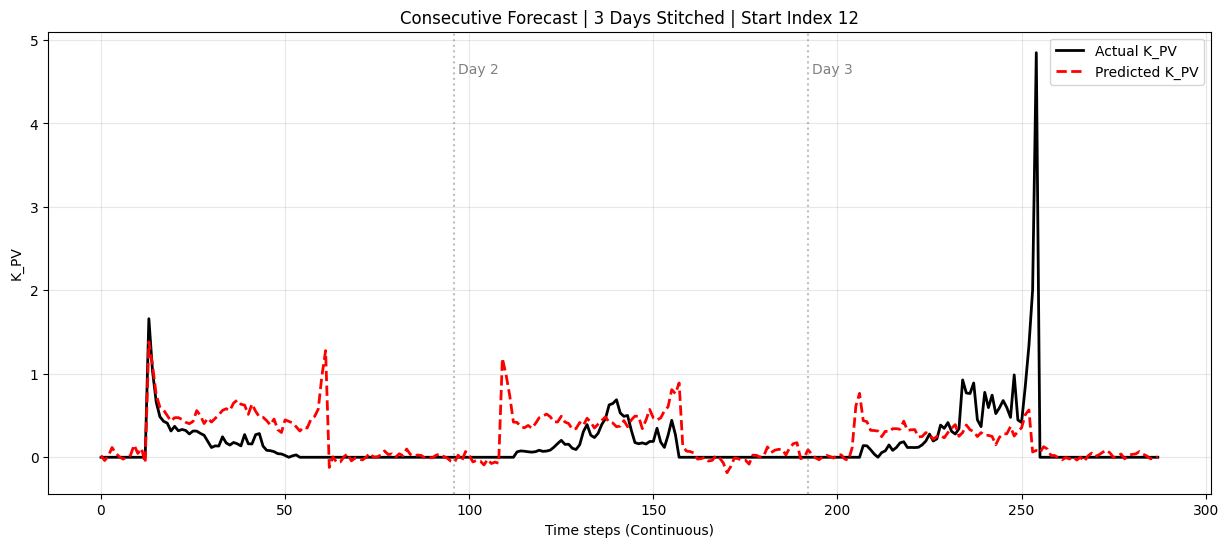

In [91]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_consecutive_series(model, loader, num_days=3, start_idx=0):
    """
    Plots consecutive days by stitching together non-overlapping forecasts.
    
    Args:
        model: The trained PyTorch model.
        loader: DataLoader (must be sequential, shuffle=False).
        num_days: How many consecutive days (horizons) to plot.
        start_idx: The index of the sample to start plotting from.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # Containers to store the full dataset outputs
    all_preds = []
    all_actuals = []
    
    # 1. Collect predictions from the loader
    # We iterate through the loader to gather enough samples to stitch together.
    # Note: For very large test sets, you might want to limit this loop.
    with torch.no_grad():
        for x_past, y_future, x_future in loader:
            x_past = x_past.to(device)
            y_future = y_future.to(device)
            x_future = x_future.to(device)

            # Forward pass
            preds = model(x_past, x_future, y_future)
            
            # Store results (move to CPU numpy)
            all_preds.append(preds.cpu().numpy())
            all_actuals.append(y_future.cpu().numpy())
    
    # 2. Concatenate all batches into one long array
    # Shape becomes: [Total_Samples, Horizon, 1]
    full_preds = np.concatenate(all_preds, axis=0)
    full_actuals = np.concatenate(all_actuals, axis=0)
    
    # Remove feature dimension if it exists -> [Total_Samples, Horizon]
    if full_preds.ndim == 3:
        full_preds = full_preds[:, :, 0]
        full_actuals = full_actuals[:, :, 0]
        
    # 3. Stitching Logic
    # We determine the horizon (length of one prediction, e.g., 24 hours)
    horizon = full_preds.shape[1]
    
    stitched_pred = []
    stitched_actual = []
    
    # We loop 'num_days' times.
    # We jump by 'horizon' for each step to get the next non-overlapping day.
    # e.g. Day 1 is index 0. Day 2 is index 24. Day 3 is index 48.
    current_idx = start_idx
    
    print(f"Stitching {num_days} days (Horizon={horizon} steps)...")
    
    for i in range(num_days):
        if current_idx >= len(full_preds):
            print(f"Warning: Not enough data in loader to plot day {i+1}")
            break
            
        # Extract the sequence for this day
        stitched_pred.append(full_preds[current_idx])
        stitched_actual.append(full_actuals[current_idx])
        
        # Jump ahead by the horizon length
        current_idx += horizon

    # Flatten the list of arrays into one continuous time series
    if not stitched_pred:
        print("No data found to plot.")
        return

    stitched_pred = np.concatenate(stitched_pred)
    stitched_actual = np.concatenate(stitched_actual)
    
    # 4. Plot
    plt.figure(figsize=(15, 6))
    
    # Plot Actual
    plt.plot(stitched_actual, label='Actual K_PV', color='black', linewidth=2)
    
    # Plot Prediction
    plt.plot(stitched_pred, label='Predicted K_PV', color='red', linestyle='--', linewidth=2)
    
    # Visual Dividers for days
    for i in range(1, num_days):
        plt.axvline(x=i * horizon, color='gray', linestyle=':', alpha=0.5)
        plt.text(i * horizon + 1, np.max(stitched_actual)*0.95, f'Day {i+1}', fontsize=10, color='gray')

    plt.title(f'Consecutive Forecast | {num_days} Days Stitched | Start Index {start_idx}')
    plt.xlabel('Time steps (Continuous)')
    plt.ylabel('K_PV')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Usage Example ---
last_fold = phys_results[-1]
model_final = last_fold['model']
loader_final = last_fold['test_loader'] 

# Plot a 3-day continuous timeline starting from the very first sample
plot_consecutive_series(model_final, loader_final, num_days=3, start_idx=12)

# Plot a 5-day continuous timeline starting from sample 100
# plot_consecutive_series(model_final, loader_final, num_days=5, start_idx=100)